In [1]:
library(Seurat)
library(gridExtra)
library(future)
library(ggplot2)
library(SingleCellExperiment)
library(scater)

plan("multicore", workers = 24)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSe

In [2]:
rna <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/dmg_ascites_prettx.rds')
rna

An object of class Seurat 
25657 features across 2478 samples within 1 assay 
Active assay: RNA (25657 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: mnn, pca, umap

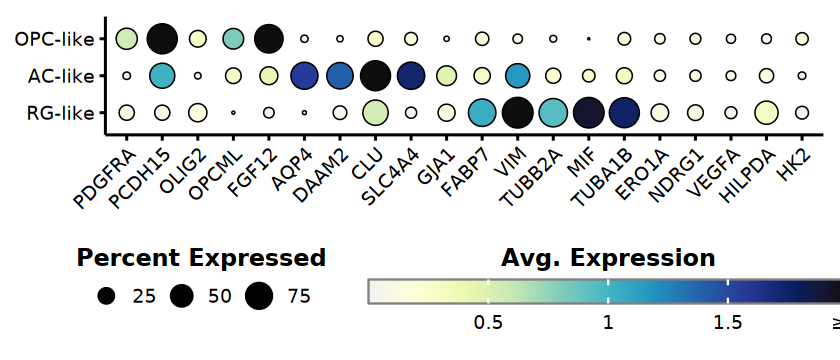

In [9]:
genes <- c(
'PDGFRA','PCDH15','OLIG2','OPCML', 'FGF12', 
    'AQP4','DAAM2', 'CLU', 'SLC4A4','GJA1',
            'FABP7','VIM',
            'TUBB2A', 'MIF',
            'TUBA1B',
    'ERO1A', 'NDRG1', 'VEGFA','HILPDA','HK2'
    
           
)

rna$celltype <- factor(rna$celltype, levels = c('OPC-like', 'AC-like', 'RG-like'))

options(repr.plot.height = 3, repr.plot.width = 7)
SCpubr::do_DotPlot(rna,features = genes,
                   max.cutoff = 2,
                   # max.cutoff = 1,
                   group.by = 'celltype',
                  )

In [10]:
ggsave('figures/dotplot_gex_case_report_primary_tumor_ascites.pdf', height = 3, width = 7)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 2' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 2' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 2' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 2' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 2' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 2' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$la

In [5]:
library(destiny)

In [6]:
sce <- Seurat::as.SingleCellExperiment(rna, assay = "RNA")
sce

class: SingleCellExperiment 
dim: 17005 2478 
metadata(0):
assays(3): counts logcounts scaledata
rownames(17005): A1BG A1CF ... ZYX ZZEF1
rowData names(0):
colnames(2478): ascites_first-prettx_AAACCCATCTCGCTCA-1
  ascites_first-prettx_AAACCCATCTTCCACG-1 ...
  primary.tumor_edge_TTTGACTCACTTGAGT-1
  primary.tumor_edge_TTTGGAGTCGACGCTG-1
colData names(11): orig.ident nCount_RNA ... OPC_variable5 ident
reducedDimNames(3): MNN PCA UMAP
mainExpName: RNA
altExpNames(0):

In [8]:
diff.map <- destiny::DiffusionMap(sce, verbose = T)

Warning message in destiny::DiffusionMap(sce, verbose = T):
“You have 17005 genes. Consider passing e.g. n_pcs = 50 to speed up computation.”


finding knns...

Warning message in (function (data, k, ..., query = NULL, distance = c("euclidean", :
“find_knn does not yet support sparse matrices, converting data to a dense matrix.”


...done. Time: 295.80s
Calculating transition probabilities...

Warning message:
“'as(<dsCMatrix>, "dsTMatrix")' is deprecated.
Use 'as(., "TsparseMatrix")' instead.
See help("Deprecated") and help("Matrix-deprecated").”


...done. Time: 0.25s

performing eigen decomposition......done. Time: 0.58s


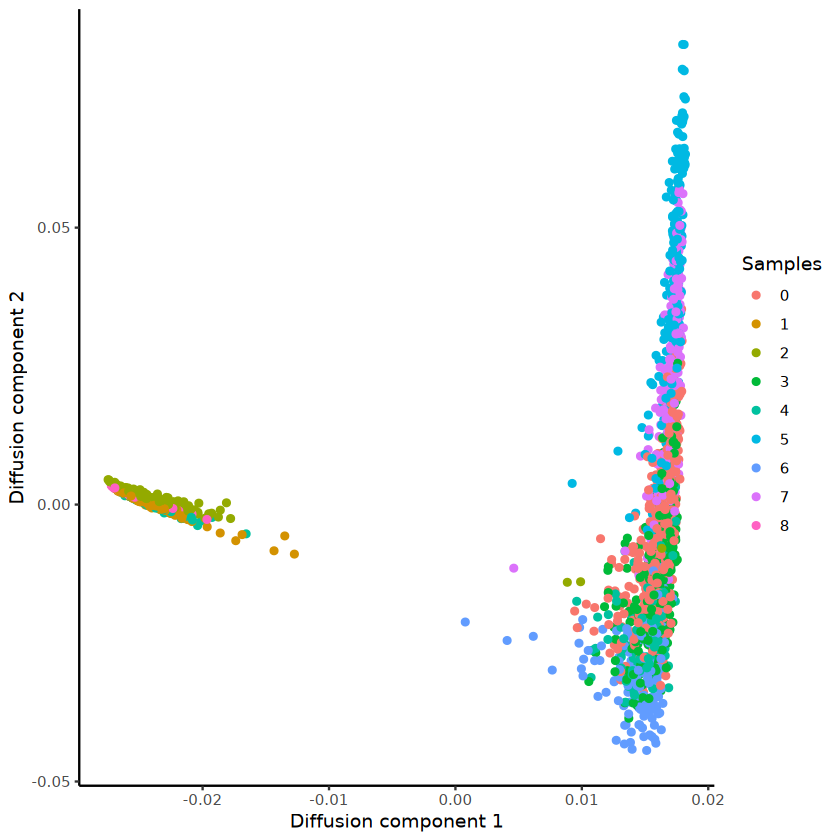

In [9]:
cellLabels <- sce$ident
tmp <- data.frame(DC1 = eigenvectors(diff.map)[, 1],
                  DC2 = eigenvectors(diff.map)[, 2],
                  DC3 = eigenvectors(diff.map)[, 3],
                  DC4 = eigenvectors(diff.map)[, 4],
                  Samples = cellLabels)

ggplot(tmp, aes(x = DC1, y = DC2, colour = Samples)) +
  geom_point()  + 
  xlab("Diffusion component 1") + 
  ylab("Diffusion component 2") +
  theme_classic()

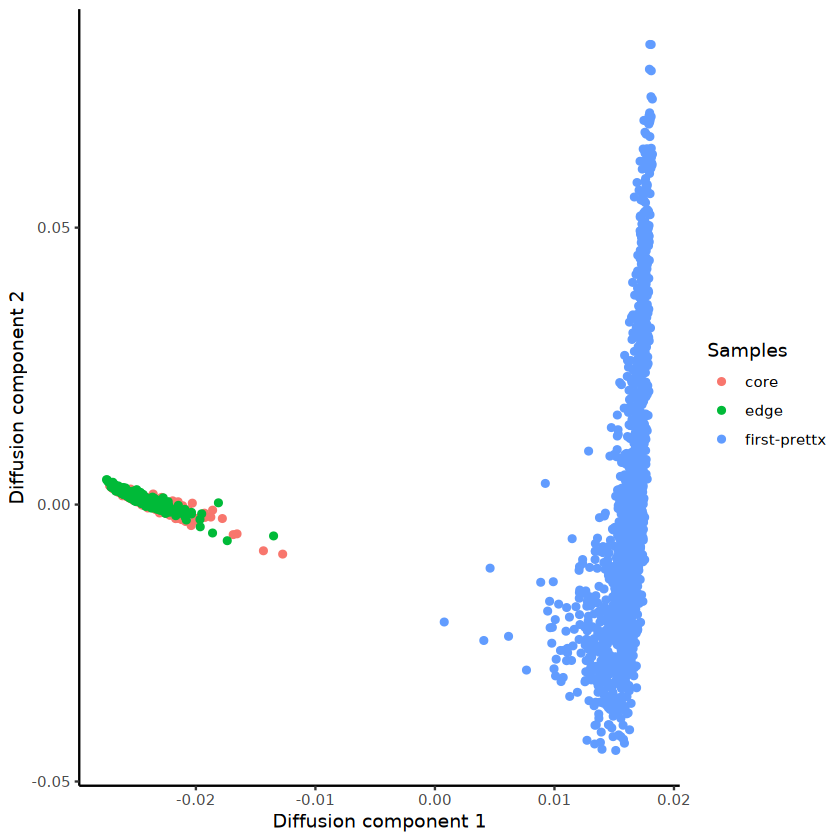

In [10]:
cellLabels <- sce$orig.ident
tmp <- data.frame(DC1 = eigenvectors(diff.map)[, 1],
                  DC2 = eigenvectors(diff.map)[, 2],
                  DC3 = eigenvectors(diff.map)[, 3],
                  DC4 = eigenvectors(diff.map)[, 4],
                  Samples = cellLabels)

ggplot(tmp, aes(x = DC1, y = DC2, colour = Samples)) +
  geom_point()  + 
  xlab("Diffusion component 1") + 
  ylab("Diffusion component 2") +
  theme_classic()

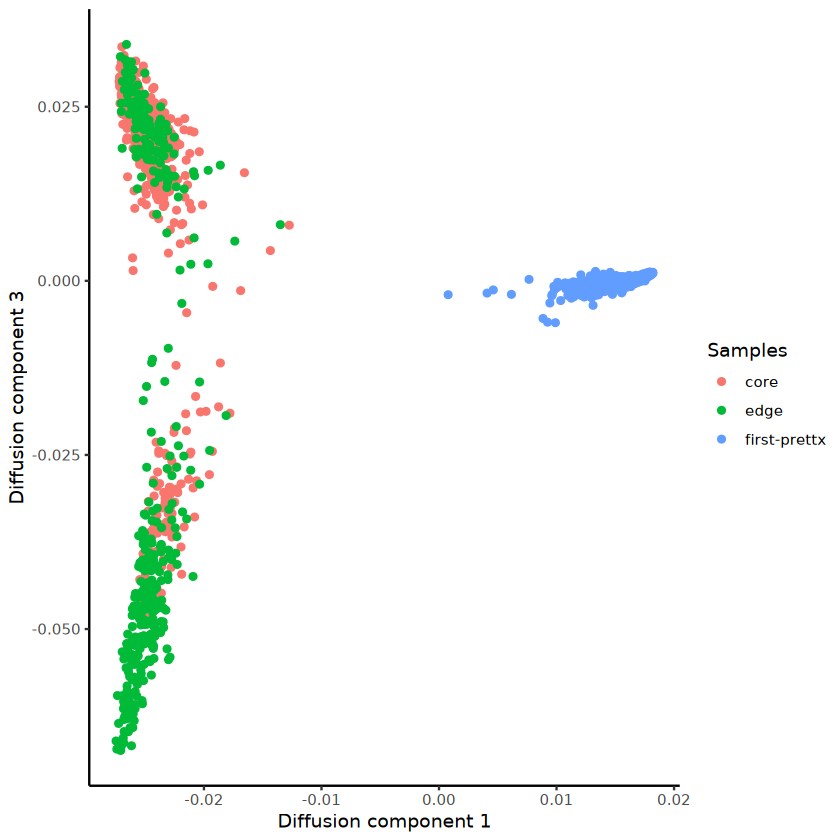

In [11]:
ggplot(tmp, aes(x = DC1, y = DC3, colour = Samples)) +
  geom_point()  + 
  xlab("Diffusion component 1") + 
  ylab("Diffusion component 3") +
  theme_classic()

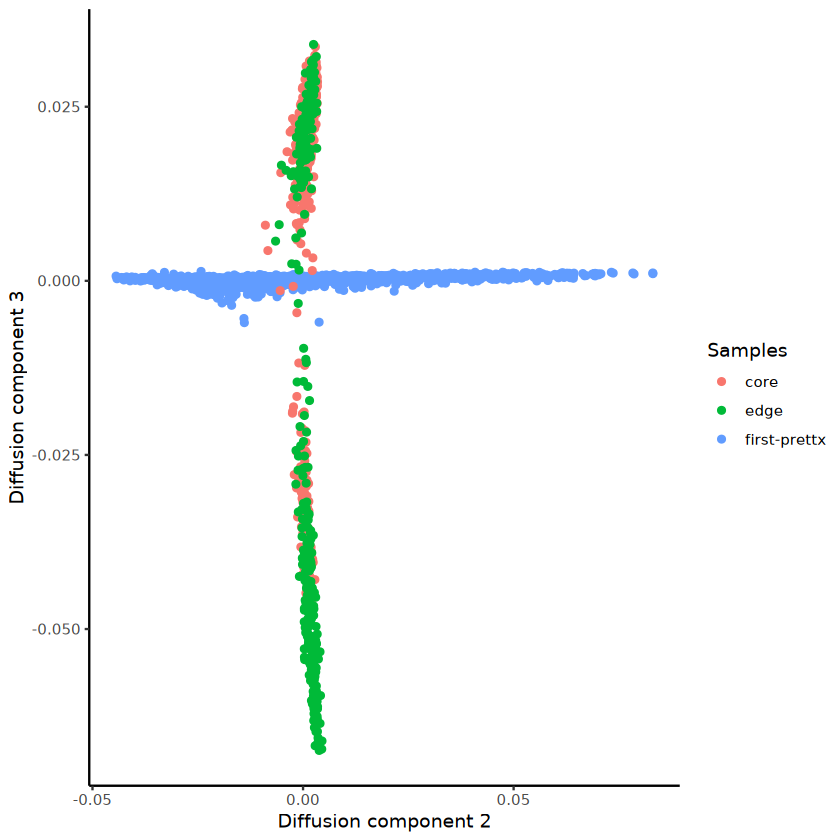

In [12]:
ggplot(tmp, aes(x = DC2, y = DC3, colour = Samples)) +
  geom_point()  + 
  xlab("Diffusion component 2") + 
  ylab("Diffusion component 3") +
  theme_classic()

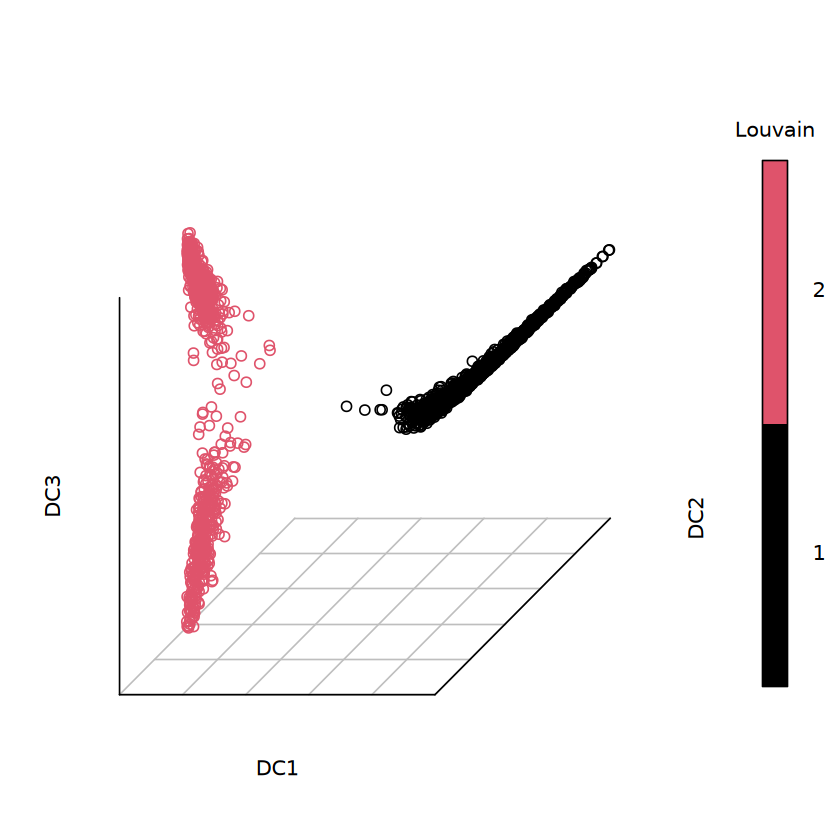

In [100]:
plot(diff.map)

In [102]:
pdf('figures/dc_primary_tumor_ascites.pdf')
plot(diff.map)
dev.off()

png 
  2

In [80]:
genes <- c("PCDH15", "FGF12", 'AQP4', 'SLC4A4',"VIM", "TUBA1B")

expr <- FetchData(rna, vars = genes)

expr$DC1 <- rna@reductions$diffmap@cell.embeddings[, "DC_1"]
expr$DC3 <- rna@reductions$diffmap@cell.embeddings[, "DC_3"]

In [81]:
expr_ordered_DC1 <- expr[order(expr$DC1), ]

expr_ordered_DC3 <- expr[order(expr$DC3), ]

In [82]:
zscore <- function(x) (x - mean(x)) / sd(x)

expr_ordered_DC1[genes] <- apply(expr_ordered_DC1[genes], 2, zscore)
expr_ordered_DC3[genes] <- apply(expr_ordered_DC3[genes], 2, zscore)

In [83]:
library(RColorBrewer)

rd_bu_colors <- rev(brewer.pal(n = 11, name = "RdBu"))
print(rd_bu_colors)

 [1] "#053061" "#2166AC" "#4393C3" "#92C5DE" "#D1E5F0" "#F7F7F7" "#FDDBC7"
 [8] "#F4A582" "#D6604D" "#B2182B" "#67001F"


In [84]:
library(circlize)

rd_bu_scale <- colorRamp2(
    c(-1, 0, 1),  
    rd_bu_colors[c(1, 6, 11)] 
)

In [85]:
ht <- Heatmap(
   t(as.matrix(expr_ordered_DC1[genes])), 
    name = "Expression",           
    col = rd_bu_scale,         
    cluster_rows = FALSE,          
    cluster_columns = FALSE,      
    show_row_names = FALSE,         
    show_column_names = FALSE,    
    column_title = "Cells Ordered by DC1"
)
print(ht)

In [86]:
pdf("heatmap_DC1_ordered.pdf", width = 10, height = 6)
draw(ht)
dev.off()

png 
  2

In [87]:

ht <- Heatmap(
    as.matrix(expr_ordered_DC3[genes]), 
    name = "Expression",          
    col = rd_bu_scale,         
    cluster_rows = FALSE,          
    cluster_columns = FALSE,    
    show_row_names = FALSE,         
    show_column_names = FALSE,     
    column_title = "Cells Ordered by DC3"
)
print(ht)

In [88]:
pdf("heatmap_DC3_ordered.pdf", width = 6, height = 10)
draw(ht)
dev.off()

png 
  2

In [2]:
malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/data/malignant_rna.rds')
malignant

An object of class Seurat 
19248 features across 291695 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [20]:
case_report <- subset(malignant, ID=='T19-91014')
case_report <- subset(case_report, MP_Assignment %in% c('unresolved', 'MP12', 'MP8'), invert=TRUE)

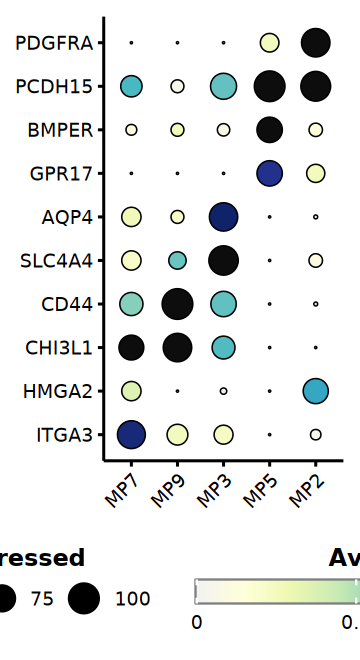

In [31]:
genes <- rev(c(
"PDGFRA","PCDH15",#OPC
"BMPER","GPR17",#COP
"AQP4","SLC4A4",#AC
    'CD44','CHI3L1',
           "HMGA2",'ITGA3'
           
))

options(repr.plot.height = 5.5, repr.plot.width = 3)
SCpubr::do_DotPlot(case_report,features = genes,max.cutoff = 1.5,
                   # max.cutoff = 1,
                   group.by = 'MP_Assignment',flip = TRUE,
                  )

In [32]:
ggsave('figures/dotplot_gex_case_report_primary_tumor.pdf', height = 5.5, width = 3)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on '≥ 1.5' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graphics(C_text, as.graphi

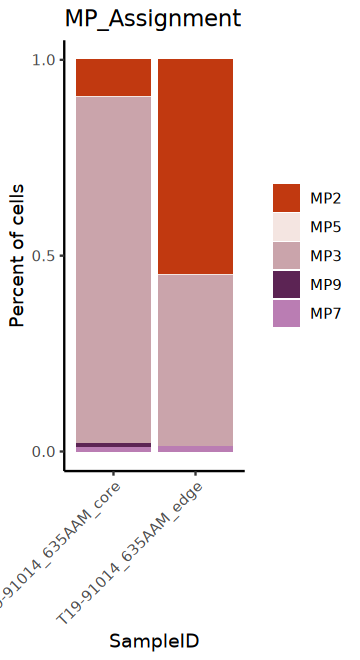

In [34]:
dittoBarPlot(case_report, retain.factor.levels = TRUE,
             var = 'MP_Assignment',
             color.panel=c(  "#c13910", 
                           "#f4e5e1",
                           "#caa4ab", 
                            "#5c2454", "#ba7db3"
                          ),
             group.by = 'SampleID')

In [36]:
ggsave('figures/barplot_cell_type_proportions_case_report_primary.pdf', height = 5.5, width = 3)